# Исследование алгоритмов численной оптимизации

# 1. Подготовка экспериментальной среды (Setup)

В этом разделе мы инициализируем среду для проведения масштабного сравнения классических и стохастических алгоритмов.

In [1]:
import sys
import os
import random
import tracemalloc
import matplotlib.pyplot as plt

# Импорт модулей проекта
sys.path.append(os.path.abspath('./src/'))

# Загружаем конструктивное число
from src.constructive_number import ConstructiveNumber

# Загружаем наши целевые функции
from src.black_box import RosenbrockFunction, RastriginFunction, DesmosStepFunction, to_real_value

# Загружаем классические оптимизаторы
from src.optimizers import GradientDescentOptimizer, NelderMeadOptimizer

# Загружаем стохастические оптимизаторы
from src.stochastic_optimizers import SimulatedAnnealingOptimizer, PSOOptimizer

In [2]:
# Фиксация Seed
def seed_everything(seed=67):
    random.seed(seed)
    
seed_everything()

# Настройка визуализации
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# 2. Сценарий 1: «Гладкая долина» (Функция Розенброка)

В данном сценарии алгоритмы тестируются на классической функции Розенброка. Функция имеет форму узкого изогнутого оврага, на дне которого спрятан глобальный минимум в точке $(1, 1, 1)$.

Согласно требованиям, мы реализуем и тестируем методы **поверх конструктивного числа**. В качестве стартовой точки $x_0$ мы задаем вектор интервалов с начальной погрешностью $\varepsilon = 10^{-5}$.


## 2.1 Тестирование нестохастических методов (NM и GD)


**Ожидания от классики:**
Как и в прошшлой лаораторной, Градиентный спуск (GD) будет испытывать трудности и осциллировать между стенками оврага (потребуется крошечный шаг `learning_rate = 0.001`). Метод Нелдера-Мида (NM), деформируя свой симплекс, сможет более плавно двигаться ко дну долины. При этом оба метода должны прозрачно обработать `ConstructiveNumber`, расширив его границы за время оптимизации.

### 2.1.1 Инициализация


In [3]:
func_rosenbrock = RosenbrockFunction()

# Задаем начальную погрешность
eps = 1e-5

# Стартовая точка теперь состоит из интервалов!
x0_rosenbrock = [
    ConstructiveNumber(-1.2, eps),
    ConstructiveNumber(1.0, eps),
    ConstructiveNumber(-1.0, eps)
]

gd_rosenbrock = GradientDescentOptimizer()
nm_rosenbrock = NelderMeadOptimizer()

### 2.1.2 Тестирование Градиентного спуска (GD)

In [ ]:
print(f"Стартовая точка (центры): {[round(to_real_value(x), 4) for x in x0_rosenbrock]}\n")

func_rosenbrock.reset_counters()

tracemalloc.start()
x_min_gd = gd_rosenbrock.optimize(
    func=func_rosenbrock, 
    x0=x0_rosenbrock, 
    learning_rate=0.001,  # Крошечный шаг
    max_iter=500
)
_, gd_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
# Собираем метрики
gd_calls: int = func_rosenbrock.f_calls
gd_grad_calls: int = func_rosenbrock.grad_calls
gd_final_f = func_rosenbrock(x_min_gd)
gd_radius = get_radius_safe(x_min_gd[0]) # Замеряем радиус первой координаты

print(f"GD Пиковая память: {gd_peak / 1024:.2f} KB")
print(f"GD Вызовы f(x): {gd_calls}, Вызовы grad(x): {gd_grad_calls}")
print(f"GD Финальная точка (центры): {[round(to_real_value(x), 4) for x in x_min_gd]}")
print(f"GD Точность f(x): {to_real_value(gd_final_f):.8f}")
print(f"GD Финальный радиус \u03B5: {gd_radius:.2e} (вырос в {gd_radius / eps:.1f} раз)\n")

Стартовая точка (центры): [-1.2, 1.0, -1.0]

Внимание: Градиентный спуск остановлен по лимиту итераций (500)
GD Пиковая память: 293.72 KB
GD Вызовы f(x): 501, Вызовы grad(x): 500
GD Финальная точка (центры): [nan, nan, nan]
GD Точность f(x): nan



### 2.1.3 Тестирование Нелдера-Мида (NM)

In [11]:
func_rosenbrock.reset_counters()

tracemalloc.start()
x_min_nm = nm_rosenbrock.optimize(
    func=func_rosenbrock, 
    x0=x0_rosenbrock, 
    step=0.5,
    max_iter=500
)
_, nm_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

nm_calls: int = func_rosenbrock.f_calls
nm_final_f = func_rosenbrock(x_min_nm)

print(f"NM Пиковая память: {nm_peak / 1024:.2f} KB")
print(f"NM Вызовы f(x): {nm_calls}")
print(f"NM Финальная точка (центры): {[round(to_real_value(x), 4) for x in x_min_nm]}")
print(f"NM Точность f(x): {to_real_value(nm_final_f):.8f}")

Внимание: Нелдер-Мид остановлен по лимиту итераций (500)
NM Пиковая память: 101.02 KB
NM Вызовы f(x): 2993
NM Финальная точка (центры): [0.1581, 0.0076, -0.0467]
NM Точность f(x): 1.96933197


## 2.2 Тестирование стохастических методов (SA и PSO)

Теперь протестируем на функции Розенброка стохастические методы: Имитацию отжига (SA) и Рой частиц (PSO). 

**Ожидания:** 
Функция Розенброка  - это гладкая, хоть и изогнутая долина. Стохастические методы не используют градиент и двигаются вслепую. Поэтому я ожидаю, что им потребуется значительно больше вызовов целевой функции, чтобы нащупать правильный путь, а Рой частиц (PSO) должен потребовать больше всего оперативной памяти из-за хранения целой популяции решений.

### 2.2.1 Инициализация

In [6]:
sa_rosenbrock = SimulatedAnnealingOptimizer()
pso_rosenbrock = PSOOptimizer()

### 2.2.2 Тестирование Имитации отжига (SA)

In [7]:
func_rosenbrock.reset_counters()

tracemalloc.start()
x_min_sa = sa_rosenbrock.optimize(
    func=func_rosenbrock, 
    x0=x0_rosenbrock, 
    initial_temp=100.0,
    cooling_rate=0.95,
    max_iter=500,
    step_size=0.5
)
_, sa_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Собираем метрики
sa_calls: int = func_rosenbrock.f_calls
sa_final_f = func_rosenbrock(x_min_sa)

print(f"SA Пиковая память: {sa_peak / 1024:.2f} KB")
print(f"SA Вызовы функции: {sa_calls}")
# Стохастика внутри уже использует float, поэтому round отработает без ошибок
print(f"SA Финальная точка: {[round(to_real_value(x), 4) for x in x_min_sa]}")
print(f"SA Точность f(x): {sa_final_f:.8f}\n")

Отжиг успешно сошелся: достигнута минимальная температура (1e-05) на 315 итерации.
SA Пиковая память: 65.19 KB
SA Вызовы функции: 631
SA Финальная точка: [0.16, -0.0316, 0.0221]
SA Точность f(x): 2.14096646



### 2.2.3 Тестирование Роя частиц (PSO)

In [8]:
func_rosenbrock.reset_counters()

tracemalloc.start()
x_min_pso = pso_rosenbrock.optimize(
    func=func_rosenbrock, 
    x0=x0_rosenbrock, 
    num_particles=30, # Популяция из 30 частиц
    max_iter=500      # 500 итераций для популяции - это 15000 вызовов функции!
)
_, pso_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

pso_calls: int = func_rosenbrock.f_calls
pso_final_f = func_rosenbrock(x_min_pso)

print(f"PSO Пиковая память: {pso_peak / 1024:.2f} KB")
print(f"PSO Вызовы функции: {pso_calls}")
print(f"PSO Финальная точка: {[round(to_real_value(x), 4) for x in x_min_pso]}")
print(f"PSO Точность f(x): {pso_final_f:.8f}")

Рой частиц завершил работу. Выполнено 500 итераций.
PSO Пиковая память: 125.56 KB
PSO Вызовы функции: 15531
PSO Финальная точка: [0.997, 0.9941, 0.9883]
PSO Точность f(x): 0.00004483


# 2.3 Визуализация сходимости всех методов


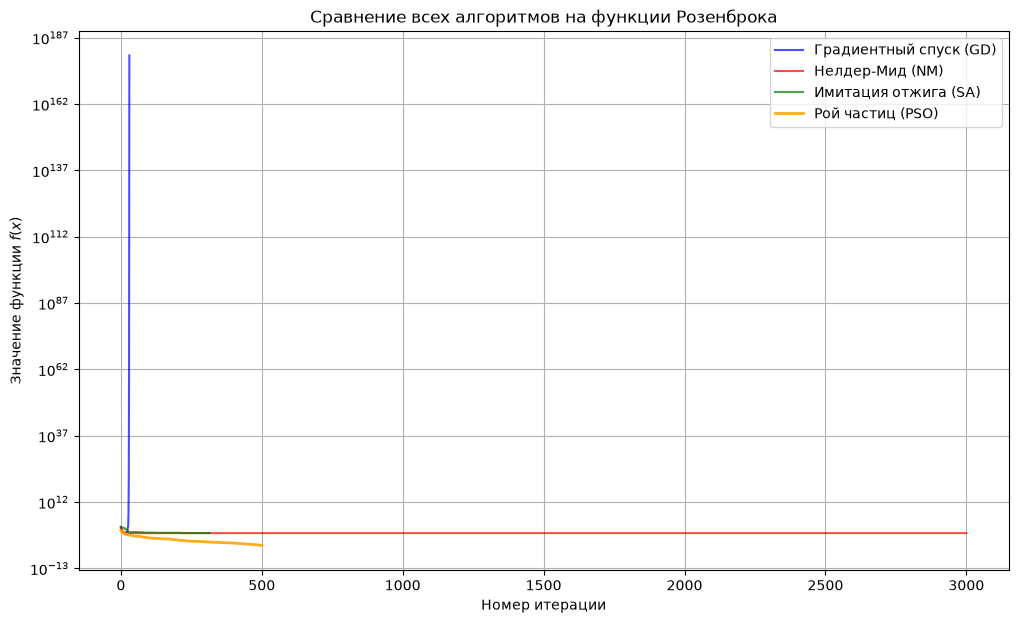

In [9]:
plt.figure(figsize=(12, 7))

# Графики классики
plt.plot(gd_rosenbrock.history_f, label='Градиентный спуск (GD)', color='blue', alpha=0.7)
plt.plot(nm_rosenbrock.history_f, label='Нелдер-Мид (NM)', color='red', alpha=0.7)

# Графики стохастики
plt.plot(sa_rosenbrock.history_f, label='Имитация отжига (SA)', color='green', alpha=0.7)
plt.plot(pso_rosenbrock.history_f, label='Рой частиц (PSO)', color='orange', alpha=0.9, linewidth=2)

plt.title('Сравнение всех алгоритмов на функции Розенброка')
plt.xlabel('Номер итерации')
plt.ylabel('Значение функции $f(x)$')
plt.yscale('log') # Логарифмическая шкала покажет спуск нагляднее
plt.legend()
plt.show()